In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/laveshjadon/ai-impact-on-students/ai_student_impact_dataset (1).csv


In [2]:
!pip install scikeras

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scikeras.wrappers import KerasRegressor
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    mean_absolute_percentage_error
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import warnings
warnings.filterwarnings('ignore')
 

In [8]:
df = pd.read_csv('/kaggle/input/datasets/laveshjadon/ai-impact-on-students/ai_student_impact_dataset (1).csv')

In [9]:
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [10]:
df.shape

(50000, 16)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [12]:
df.isnull().sum()

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

In [13]:
le_encoder=LabelEncoder()
df['Major_Category']= le_encoder.fit_transform(df['Major_Category'])
df['Year_of_Study']= le_encoder.fit_transform(df['Year_of_Study'])
df['Primary_Use_Case']= le_encoder.fit_transform(df['Primary_Use_Case'])
df['Institutional_Policy']= le_encoder.fit_transform(df['Institutional_Policy'])

In [14]:
or_encoder=OrdinalEncoder()
df['Prompt_Engineering_Skill']= or_encoder.fit_transform(df[['Prompt_Engineering_Skill']])
df['Burnout_Risk_Level']= or_encoder.fit_transform(df[['Burnout_Risk_Level']])

In [15]:
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,2,3,2.418,23.31,0,1.0,1,True,8.13,5,1,6,2.393,86.44,0.0
1,100002,3,2,3.821,1.12,3,0.0,5,False,16.65,3,1,9,3.696,69.39,1.0
2,100003,1,0,3.398,21.26,4,1.0,2,False,10.35,5,2,9,3.499,73.93,2.0
3,100004,1,3,3.789,1.82,0,2.0,4,False,15.23,2,1,2,4.000,63.58,2.0
4,100005,4,4,3.635,9.29,1,0.0,4,False,12.55,4,1,4,3.798,100.00,2.0


In [16]:
x=df.drop(columns=['Student_ID','Post_Semester_GPA'])
y=df['Post_Semester_GPA']

In [17]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.33, random_state=42)

In [18]:
scaler = StandardScaler()

xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)

In [19]:
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(x.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='linear')) # Linear output for regression

2026-07-22 16:42:41.316825: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [20]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [21]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [22]:
history= model.fit(xtrain, ytrain,
          epochs=100,
          batch_size=64,
          validation_data=(xtest, ytest),
          callbacks=[early_stop]
         )

Epoch 1/100
524/524 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9147 - mae: 0.5804 - val_loss: 0.1145 - val_mae: 0.2693
Epoch 2/100
524/524 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0821 - mae: 0.2272 - val_loss: 0.0585 - val_mae: 0.1926
Epoch 3/100
524/524 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0460 - mae: 0.1701 - val_loss: 0.0368 - val_mae: 0.1516
Epoch 4/100
524/524 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0339 - mae: 0.1451 - val_loss: 0.0305 - val_mae: 0.1368
Epoch 5/100
524/524 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0303 - mae: 0.1368 - val_loss: 0.0286 - val_mae: 0.1327
Epoch 6/100
524/524 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0288 - mae: 0.1333 - val_loss: 0.0271 - val_mae: 0.1294
Epoch 7/100
524/524 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0279 - mae: 0.1309 - val_loss: 0.0271 - val_mae: 0.1302
Epoch 8/100
524/524 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0276 - mae: 0.1306 - val_loss: 0.0271 - val_mae: 0.1295
Epoch 9/100
524/524 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

In [23]:
y_pred = model.predict(xtest)

516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 845us/step


In [24]:
mape = mean_absolute_percentage_error(ytest, y_pred)
accuracy = (1 - mape) * 100

print("MAPE:", mape)
print("Accuracy %:", accuracy)
training_loss = history.history['loss'][-1]
validation_loss = history.history['val_loss'][-1]

print("Training Loss   :", training_loss)
print("Validation Loss :", validation_loss)

MAPE: 0.03599569075779563
Accuracy %: 96.40043092422044
Training Loss   : 0.02108815684914589
Validation Loss : 0.02165079303085804


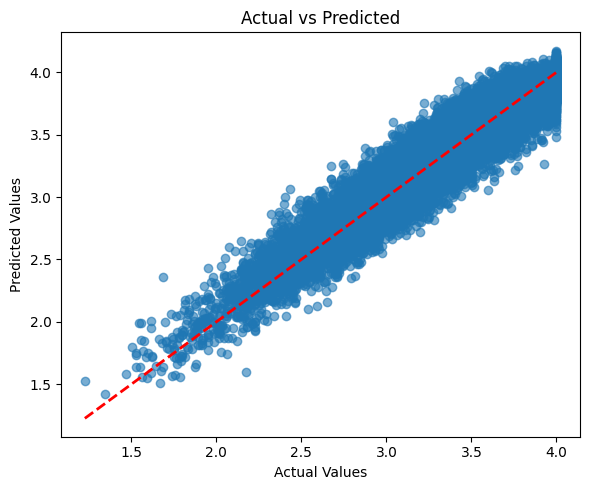

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(ytest, y_pred, alpha=0.6)
plt.plot([ytest.min(), ytest.max()],
         [ytest.min(), ytest.max()],
         'r--', lw=2)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.show()

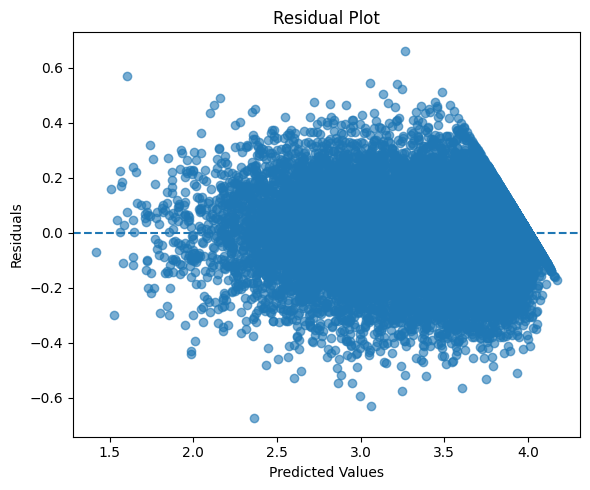

In [26]:
residuals = ytest - y_pred.flatten()

plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

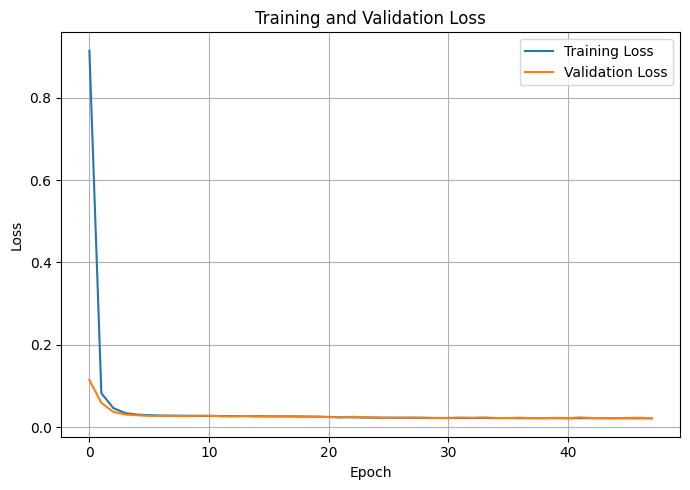

In [27]:
plt.figure(figsize=(7,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
training_mae = history.history['mae'][-1]
validation_mae = history.history['val_mae'][-1]

print("Training MAE    :", training_mae)
print("Validation MAE  :", validation_mae)

Training MAE    : 0.1146034449338913
Validation MAE  : 0.1156163290143013


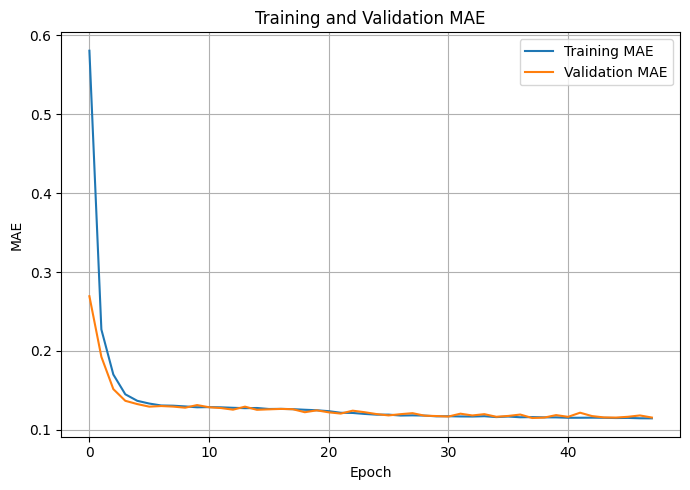

In [29]:
plt.figure(figsize=(7,5))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')

plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training and Validation MAE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae  = mean_absolute_error(ytest, y_pred)
mse  = mean_squared_error(ytest, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(ytest, y_pred)
mape = mean_absolute_percentage_error(ytest, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.4f}")

MAE  : 0.1150
MSE  : 0.0214
RMSE : 0.1464
R²   : 0.9124
MAPE : 0.0360


In [31]:
model.save('ai_student_impact_model.keras')